# CM2 Project 2 – Custom Deep Neural Networks and Training Stability

## Build, customize, and train deep neural networks using TensorFlow

In this project, I am extending the work of CM2_Project1 into deep learning by looking more closely at what happens during training, how architectural decisions affect behavior, and how stabilization techniques can improve results.

## Step 1 – Objective and Project Framing

The purpose of this project is to move beyond a basic deep neural network and explore how customization changes model behavior. Instead of treating the network like a black box, I wanted to look at the training process more directly: how the model converges, where instability shows up, and what design choices help with generalization.

More specifically, this notebook focuses on three ideas:

- **Architectural customization** such as deeper layers, dropout, and batch normalization
- **Custom TensorFlow functions** that allow more control over activations and loss behavior
- **Training stabilization techniques** that make optimization more controlled and reliable

The goal is not just to report performance metrics. The bigger goal is to explain *why* the model behaves the way it does.


## Step 2 – Reproducing the Project 1 Baseline

To keep this notebook connected to my previous CM2 work, I begin by loading the final baseline model and training pipeline from Project 1. That gives me a clean reference point for comparison before I introduce any changes.

### Baseline loading


Saving Pleasant_CM2_Project1.ipynb to Pleasant_CM2_Project1 (1).ipynb
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6637 - loss: 0.5656 - val_accuracy: 0.8098 - val_loss: 0.4194
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7887 - loss: 0.4311 - val_accuracy: 0.8124 - val_loss: 0.4088
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7994 - loss: 0.4171 - val_accuracy: 0.8098 - val_loss: 0.4080
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8080 - loss: 0.4190 - val_accuracy: 0.8062 - val_loss: 0.4019
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8159 - loss: 0.3861 - val_accuracy: 0.8142 - val_loss: 0.4053
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8184 - loss: 0.3985 - val_accuracy: 0.8080 - val_loss: 0.4066
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8149 - loss: 0.3982 - val_accuracy: 0.8062 - val_loss: 0.4021
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8237 - loss: 0.3837 - val_accuracy: 0

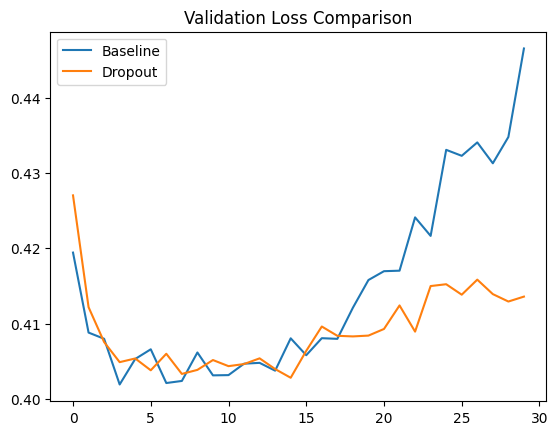

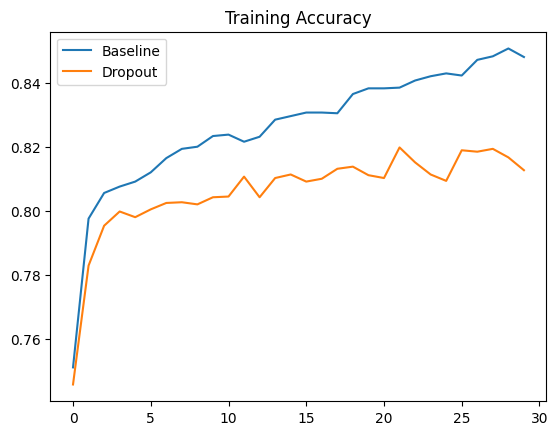

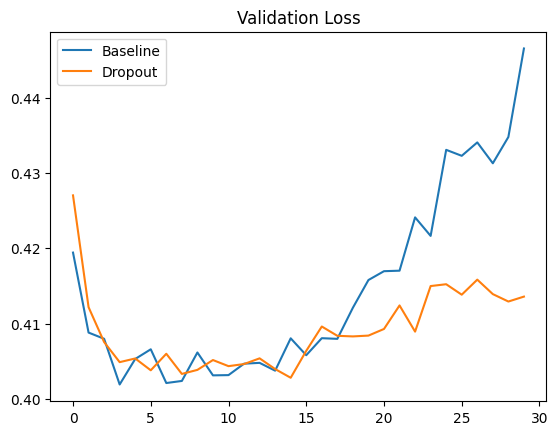

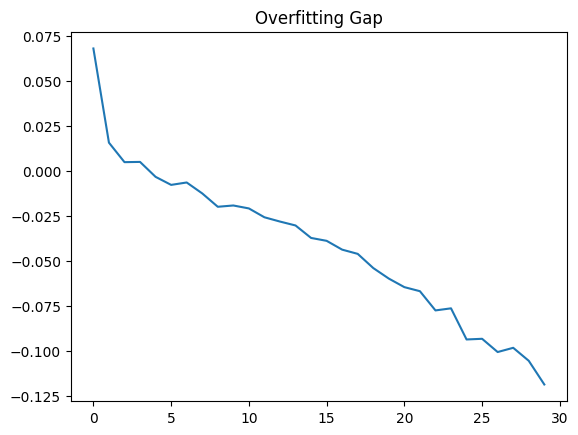

In [ ]:
%run "data_preprocessing.ipynb"

### Baseline Model Notes

The imported baseline model is a `tf.keras.Sequential` network with two hidden `Dense` layers and a sigmoid output layer for binary classification. It uses **binary crossentropy** as the loss function and evaluates performance using **accuracy**.

This matters because I need a stable point of comparison. By starting from the same baseline I used in Project 1, I can make clearer claims about what changed and why.

From Project 1, the main pattern I observed was this: training improved steadily, but validation behavior suggested that the model could begin to overfit as training continued. That makes the baseline a good starting point for testing whether architectural changes and stabilization techniques actually improve generalization.


## Step 3 – Architectural Customization

In this section, I modify the baseline architecture so the network has more capacity and better control over training behavior. I chose changes that make sense together rather than changing things at random.

### Changes applied
1. **Increased network depth** by adding another hidden layer  
2. **Adjusted layer width** to give earlier layers more representational capacity  
3. **Added dropout** to reduce overfitting  
4. **Added batch normalization** to make training more stable

The point here is not just to make the network bigger. The point is to see whether a more carefully structured architecture can learn useful patterns while keeping validation behavior under control.


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# The input shape comes from the Project 1 preprocessing pipeline.
# Reusing the same preprocessed feature space keeps the comparison fair.
input_shape = X_train.shape[1]

def create_custom_model(input_shape):
    model = keras.Sequential([
        # First hidden block:
        # Start wider than the baseline so the network has room to learn
        # higher-level feature interactions early in training.
        layers.Dense(128, input_shape=(input_shape,)),
        layers.BatchNormalization(),   # Helps stabilize internal activations
        layers.Activation('relu'),
        layers.Dropout(0.3),           # Reduces overfitting by randomly dropping units

        # Second hidden block:
        # Narrow the representation gradually instead of sharply.
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Third hidden block:
        # This extra layer increases depth compared with the baseline.
        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Binary classification output
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Build the customized model
custom_model = create_custom_model(input_shape)

# Use the same core optimization setup as the baseline so the comparison
# stays focused on architecture rather than multiple changing variables.
custom_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

custom_model.summary()

print("\n--- Training Custom Model with Architectural Changes ---")

# Train on the same data pipeline used in Project 1.
# Using validation data during training makes it easier to see whether the
# additional depth is actually helping or just fitting the training set harder.
history_custom = custom_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Why these changes were made:
# - More depth gives the network a chance to learn more layered feature patterns.
# - Batch normalization helps smooth optimization and can reduce training instability.
# - Dropout acts as regularization, which is especially useful once model capacity increases.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)


--- Training Custom Model with Architectural Changes ---
Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6408 - loss: 0.6530 - val_accuracy: 0.7669 - val_loss: 0.4581
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7566 - loss: 0.4856 - val_accuracy: 0.7797 - val_loss: 0.4439
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7838 - loss: 0.4425 - val_accuracy: 0.7797 - val_loss: 0.4438
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7895 - loss: 0.4479 - val_accuracy: 0.7818 - val_loss: 0.4440
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7875 - loss: 0.4329 - val_accuracy: 0.7825 - val_loss: 0.4410
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7994 - loss: 0.4229 - val_accuracy: 0.7832 - val_loss: 0.4387
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7917 - loss: 0.4319 - val_accuracy: 0.7818 - val_loss: 0.4393
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4


--- Plotting Training and Validation Curves for the Customized Architecture ---


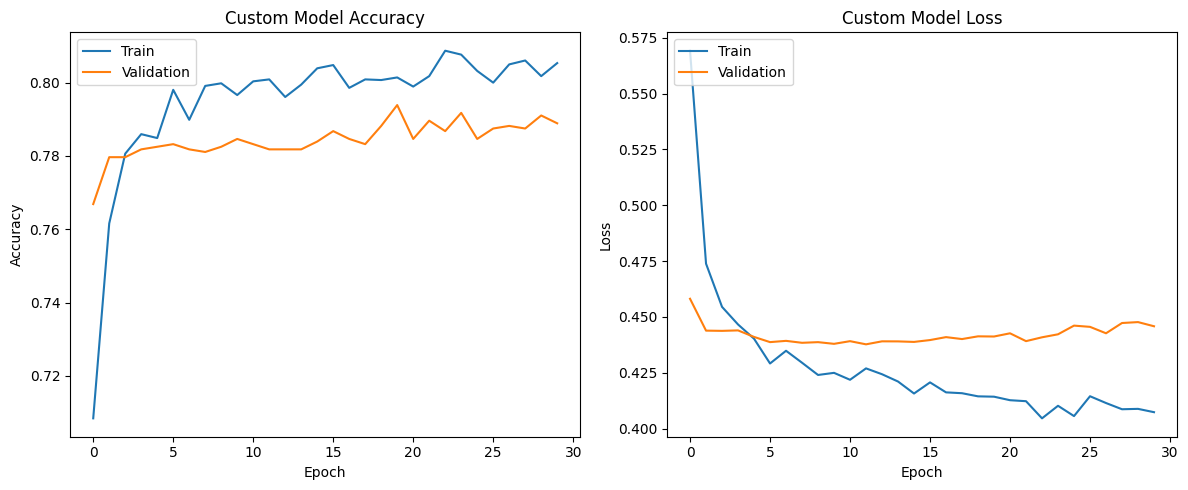

In [5]:
import matplotlib.pyplot as plt

print("\n--- Plotting Training and Validation Curves for the Customized Architecture ---")

# Learning curves are one of the easiest ways to see whether a model is
# converging cleanly or drifting toward overfitting.
plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(history_custom.history['accuracy'])
plt.plot(history_custom.history['val_accuracy'])
plt.title('Custom Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history_custom.history['loss'])
plt.plot(history_custom.history['val_loss'])
plt.title('Custom Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


### Reading the architectural learning curves

These plots show whether the deeper model is learning in a controlled way. If training accuracy rises while validation accuracy stays flat, that points toward overfitting. If the validation loss remains smoother or improves relative to the baseline, that suggests the added normalization and dropout are helping the model generalize instead of just memorize.


## Step 4 – Custom TensorFlow Functions

A key part of this assignment is moving beyond built-in defaults and showing that I can define TensorFlow behavior myself. In this section, I use two custom functions:

1. A **custom activation function**
2. A **custom weighted loss function**

I chose these because they both affect how learning happens. The activation function changes how signals move through the network, while the loss function changes how mistakes are penalized during optimization.


In [6]:
from functools import partial

# Custom TensorFlow Function 1:
# Leaky ReLU keeps a small gradient for negative values, which can help avoid
# dead neurons that sometimes occur with standard ReLU.
@tf.function
def leaky_relu_custom(x, alpha=0.2):
    return tf.maximum(alpha * x, x)

# Custom TensorFlow Function 2:
# Weighted binary crossentropy gives me more control over how the model treats
# positive and negative examples during training.
def weighted_binary_crossentropy(y_true, y_pred, pos_weight, neg_weight):
    y_pred = tf.clip_by_value(
        y_pred,
        tf.keras.backend.epsilon(),
        1 - tf.keras.backend.epsilon()
    )
    loss = -(
        y_true * pos_weight * tf.math.log(y_pred) +
        (1 - y_true) * neg_weight * tf.math.log(1 - y_pred)
    )
    return tf.reduce_mean(loss)

# Reuse the same feature shape so the comparison stays consistent
input_shape = X_train.shape[1]

def create_custom_model_with_tf_functions(input_shape):
    model = keras.Sequential([
        # Hidden block 1: custom activation
        layers.Dense(128, input_shape=(input_shape,)),
        layers.BatchNormalization(),
        layers.Activation(leaky_relu_custom),
        layers.Dropout(0.3),

        # Hidden block 2: standard ReLU for contrast
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Hidden block 3: custom activation again
        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation(leaky_relu_custom),
        layers.Dropout(0.3),

        layers.Dense(1, activation='sigmoid')
    ])
    return model

custom_model_tf = create_custom_model_with_tf_functions(input_shape)

# Wrap the custom loss so it can be passed into compile() cleanly.
weighted_bce_loss = partial(
    weighted_binary_crossentropy,
    pos_weight=1.5,
    neg_weight=1.0
)
weighted_bce_loss.__name__ = 'weighted_binary_crossentropy'

custom_model_tf.compile(
    optimizer='adam',
    loss=weighted_bce_loss,
    metrics=['accuracy']
)

custom_model_tf.summary()

print("\n--- Training Model with Custom TensorFlow Functions ---")

history_custom_tf = custom_model_tf.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)


--- Training Model with Custom TensorFlow Functions ---
Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.6479 - loss: 0.7295 - val_accuracy: 0.7520 - val_loss: 0.5680
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7516 - loss: 0.5910 - val_accuracy: 0.7505 - val_loss: 0.5572
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7767 - loss: 0.5608 - val_accuracy: 0.7569 - val_loss: 0.5543
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7733 - loss: 0.5561 - val_accuracy: 0.7626 - val_loss: 0.5504
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7813 - loss: 0.5526 - val_accuracy: 0.7669 - val_loss: 0.5494
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7879 - loss: 0.5267 - val_accuracy: 0.7633 - val_loss: 0.5490
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7847 - loss: 0.5336 - val_accuracy: 0.7761 - val_loss: 0.5504
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms


--- Plotting Training and Validation Curves for the Custom TensorFlow Function Model ---


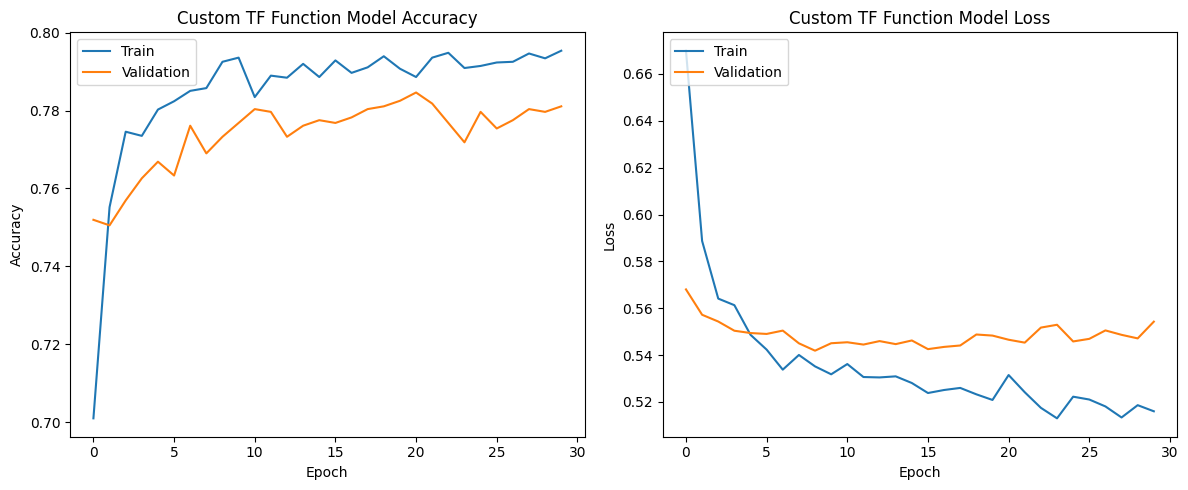

In [7]:
print("\n--- Plotting Training and Validation Curves for the Custom TensorFlow Function Model ---")

plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(history_custom_tf.history['accuracy'])
plt.plot(history_custom_tf.history['val_accuracy'])
plt.title('Custom TF Function Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history_custom_tf.history['loss'])
plt.plot(history_custom_tf.history['val_loss'])
plt.title('Custom TF Function Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


### Reading the custom-function learning curves

These plots help show whether the custom activation and weighted loss changed training behavior in a meaningful way. If convergence becomes smoother or validation performance improves, that suggests the custom functions are helping optimization. If the curves become noisier, that can indicate that the added flexibility also made training more sensitive.


## Step 5 – Training Stabilization Techniques

After changing the architecture and adding custom TensorFlow functions, the next question is whether training can be made more stable. For this part, I chose **learning rate scheduling**.

I picked this technique because the learning rate has a direct effect on optimization. If it is too aggressive, training can oscillate. If it decays in a controlled way, the model can make larger updates early on and finer adjustments later in training.


In [8]:
# Reuse the same architectural template so the stabilization experiment stays
# focused on the optimizer behavior rather than a totally different model.
input_shape = X_train.shape[1]

def create_model_with_lr_schedule(input_shape):
    model = keras.Sequential([
        layers.Dense(128, input_shape=(input_shape,)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Learning rate schedule:
# Start with the same learning rate as before, then decay it gradually so the
# optimizer can take smaller, more precise steps later in training.
initial_learning_rate = 0.001

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.9,
    staircase=True
)

optimizer_with_lr_schedule = keras.optimizers.Adam(learning_rate=lr_schedule)

model_lr_schedule = create_model_with_lr_schedule(input_shape)

model_lr_schedule.compile(
    optimizer=optimizer_with_lr_schedule,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lr_schedule.summary()

print("\n--- Training Model with Learning Rate Scheduling ---")

history_lr_schedule = model_lr_schedule.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Why this technique matters:
# A decaying learning rate can help the model move quickly at the start of
# training, then settle into more stable updates as it approaches convergence.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)


--- Training Model with Learning Rate Scheduling ---
Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6579 - loss: 0.6343 - val_accuracy: 0.7790 - val_loss: 0.4466
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7702 - loss: 0.4797 - val_accuracy: 0.7818 - val_loss: 0.4426
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7831 - loss: 0.4596 - val_accuracy: 0.7825 - val_loss: 0.4393
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7799 - loss: 0.4601 - val_accuracy: 0.7768 - val_loss: 0.4383
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7883 - loss: 0.4396 - val_accuracy: 0.7875 - val_loss: 0.4362
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7900 - loss: 0.4391 - val_accuracy: 0.7811 - val_loss: 0.4360
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7879 - loss: 0.4304 - val_accuracy: 0.7896 - val_loss: 0.4337
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/st


--- Plotting Training and Validation Curves for the Learning Rate Schedule Model ---


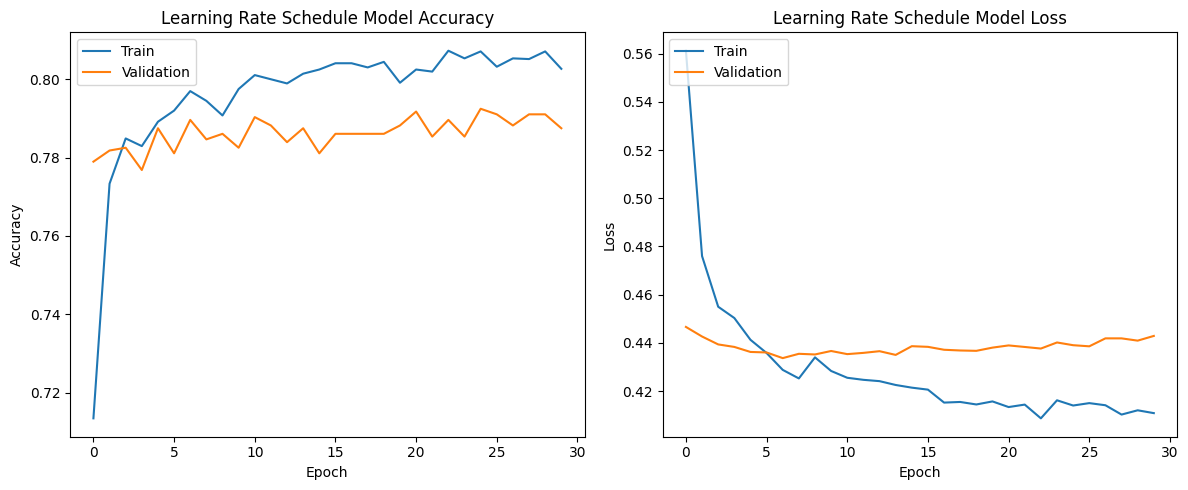

In [9]:
print("\n--- Plotting Training and Validation Curves for the Learning Rate Schedule Model ---")

plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(history_lr_schedule.history['accuracy'])
plt.plot(history_lr_schedule.history['val_accuracy'])
plt.title('Learning Rate Schedule Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history_lr_schedule.history['loss'])
plt.plot(history_lr_schedule.history['val_loss'])
plt.title('Learning Rate Schedule Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


### Reading the stabilization learning curves

The main thing I am looking for here is smoother convergence. A successful stabilization technique should reduce erratic movement in the loss curve and help the model maintain better alignment between training and validation performance. In other words, I want to see not just learning, but controlled learning.


## Step 6 – Comparative Analysis

Now that the baseline, customized architecture, custom-function model, and stabilization model have all been trained, I can compare them more directly. I am paying attention to three things:

- **Convergence speed** – how quickly the model improves
- **Training stability** – whether the curves are smooth or erratic
- **Generalization behavior** – whether validation metrics stay aligned with training metrics

This is where the notebook shifts from building models to interpreting what the training process is actually telling me.


### Model-by-model comparison

#### 1. Baseline model
The baseline converges in a straightforward way, but its learning curves suggest that validation performance does not improve as consistently as training performance. That pattern is a reminder that optimization success and generalization success are not the same thing.

#### 2. Customized architecture
The deeper architecture introduces more representational capacity. Batch normalization and dropout help keep that extra capacity from turning immediately into overfitting. If the validation curves become smoother than the baseline, that is evidence that the architectural changes improved training behavior rather than just increasing complexity.

#### 3. Custom TensorFlow function model
This version gives me more direct control over how the network learns. The custom activation changes how gradients flow through the network, while the weighted loss changes how prediction errors are emphasized. If the model responds well, it suggests that carefully chosen custom functions can make training behavior more intentional instead of relying only on defaults.

#### 4. Learning rate schedule model
This model is the clearest test of training stability. If the loss curves become more controlled or convergence appears less noisy, then the learning rate schedule is doing what it is supposed to do: helping the optimizer make large early moves and smaller later refinements.


## Step 7 – Interpretation Through CM2 Concepts

To make sense of the results, I want to connect the observed behavior back to the main deep learning ideas from CM2 rather than treating the output as a collection of plots and metrics.

### Baseline behavior
The baseline model shows that a network can learn useful patterns while still drifting toward overfitting. This is a common deep learning result: training loss can continue improving even after validation behavior stops improving. That is why validation metrics matter more than training metrics alone when judging model quality.

### Effect of architectural changes
Adding depth increases the model's ability to learn more complex feature interactions, but it also increases the risk of overfitting. Batch normalization and dropout act as balancing forces. Batch normalization can make optimization smoother, while dropout reduces reliance on any one pathway through the network. Together, they help the model learn with more control.

### Effect of custom TensorFlow functions
The custom activation and weighted loss show that training behavior is not fixed. By defining pieces of the computation directly, I can influence how information flows through the model and how errors are penalized. This reinforces the idea that TensorFlow is not just a model library; it is also a framework for shaping learning behavior.

### Effect of the stabilization technique
Learning rate scheduling highlights the importance of optimization dynamics. A model does not only need a good architecture; it also needs an update process that behaves well over time. If the learning rate stays too high throughout training, the optimizer can overshoot good regions. Decay helps the model shift from fast early learning to more refined later updates.

### Overall takeaway
What stands out most in this project is that neural network performance is shaped by the interaction of **capacity, regularization, and optimization**. A stronger model is not simply a larger one. It is a model whose training process is controlled well enough to produce stable learning and better generalization.


## Step 8 – Conclusion

This project felt like a natural extension of the modeling work I did earlier in CC5. The difference is that here I had to pay much closer attention to *how* the model learned, not just *how well* it scored.

By reproducing the Project 1 baseline, customizing the architecture, defining custom TensorFlow functions, and applying a stabilization technique, I was able to see that deep learning performance depends on more than accuracy alone. It depends on whether the model converges cleanly, whether validation behavior remains stable, and whether the training setup supports generalization instead of memorization.

Overall, this project strengthened my understanding of neural network design, optimization behavior, and training stability in a way that clearly builds on my previous coursework.
